# 🎬 Task 5: Movie Recommendation System

**Problem:** Predict which movies a user will like by comparing them with users who share similar
tastes, and return a ranked list of movies they haven't seen yet — a classic **collaborative
filtering** task.

**Dataset:** [MovieLens (GroupLens)](https://grouplens.org/datasets/movielens/) — we use the
`ml-latest-small` variant (100,836 ratings, 610 users, 9,724 movies; the same family as the
recommended MovieLens 100K). Ratings are on a **0.5–5.0 half-point scale**.

**Objective:** Build a **user-based collaborative filtering** recommender — user–item matrix,
user–user similarity, and top-rated unseen movies for any user — and evaluate it with
**precision@K**. Bonus: **item-based collaborative filtering** and **SVD matrix factorization**,
compared side by side.

## 2. Imports & Setup

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix

import gradio as gr

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = "dataset"
RATINGS_PATH = os.path.join(DATA_DIR, "ratings.csv")
MOVIES_PATH = os.path.join(DATA_DIR, "movies.csv")

# Preprocessing / recommender constants
MIN_MOVIE_RATINGS = 10    # drop movies with fewer than 10 ratings (popularity filter)
MIN_USER_RATINGS = 10     # users need >= 10 ratings to be eligible for evaluation
MIN_HIGH_RATED = 5        # ... and >= 5 high-rated (>= 4.0) movies for a meaningful test set
HIGH_RATING_THRESHOLD = 4.0
TEST_FRACTION = 0.2       # per-user fraction of high-rated movies held out for testing
NEIGHBORS = 50            # top-N similar users used for user-based scoring
K_VALUES = [5, 10, 20]    # precision@K grid

MODELS_DIR = "models"
ASSETS_DIR = "assets"
for d in (MODELS_DIR, ASSETS_DIR):
    os.makedirs(d, exist_ok=True)

C:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Load & Explore Data

In [2]:
ratings = pd.read_csv(RATINGS_PATH)
movies = pd.read_csv(MOVIES_PATH)

print("ratings shape:", ratings.shape)
print("movies  shape:", movies.shape)
ratings.head()

ratings shape: (100836, 4)
movies  shape: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [4]:
print("Summary statistics:")
ratings[["rating"]].describe().T

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
rating,100836.0,3.501557,1.042529,0.5,3.0,3.5,4.0,5.0


In [5]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f"Unique users : {n_users}")
print(f"Unique movies: {n_movies}")
print(f"Total ratings: {n_ratings}")
print(f"Matrix dims  : {n_users} x {n_movies}")
print(f"Sparsity     : {sparsity * 100:.2f}% of cells are empty")
print()
print("Rating scale (half-point increments):", sorted(ratings["rating"].unique()))

Unique users : 610
Unique movies: 9724
Total ratings: 100836
Matrix dims  : 610 x 9724
Sparsity     : 98.30% of cells are empty

Rating scale (half-point increments): [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


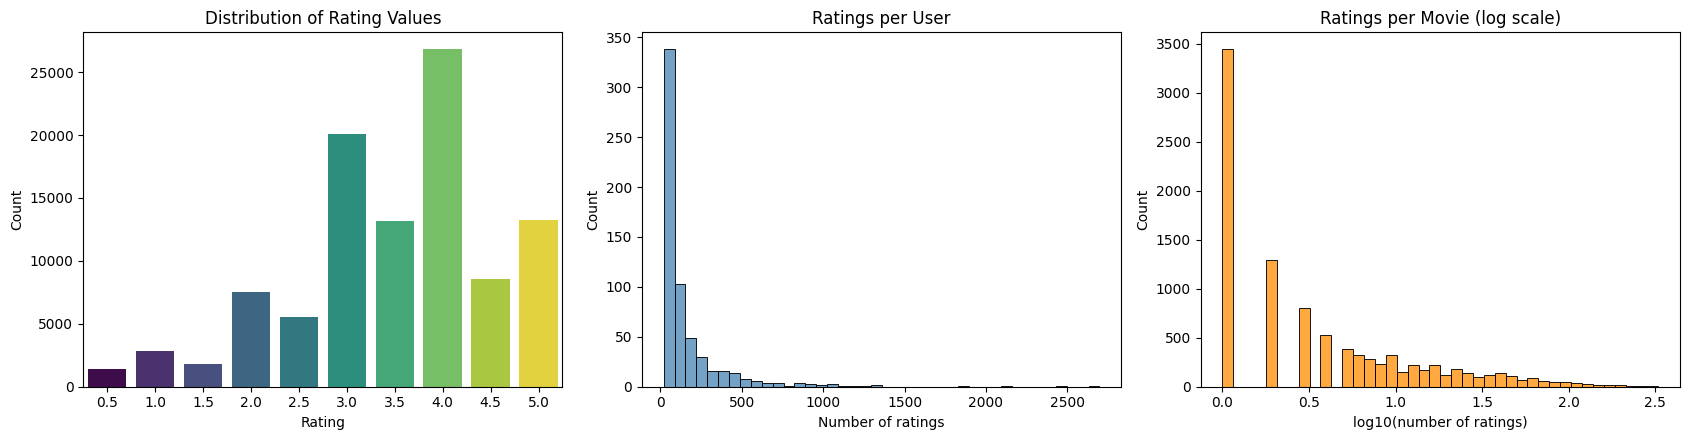

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 1) Rating value distribution
vc = ratings["rating"].value_counts().sort_index()
sns.barplot(x=vc.index.astype(float), y=vc.values, hue=vc.index.astype(float),
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Distribution of Rating Values")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# 2) Ratings per user (activity distribution)
per_user = ratings.groupby("userId").size()
sns.histplot(per_user, bins=40, kde=False, color="steelblue", ax=axes[1])
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("Number of ratings")

# 3) Ratings per movie (popularity distribution)
per_movie = ratings.groupby("movieId").size()
sns.histplot(np.log10(per_movie), bins=40, kde=False, color="darkorange", ax=axes[2])
axes[2].set_title("Ratings per Movie (log scale)")
axes[2].set_xlabel("log10(number of ratings)")

plt.tight_layout()
plt.show()

In [7]:
# Top 10 most-rated movies (merge titles in only for display — computation stays on ratings)
top_movies = (
    per_movie.sort_values(ascending=False).head(10)
    .reset_index().rename(columns={"movieId": "movieId", 0: "count"})
)
top_movies = top_movies.merge(movies[["movieId", "title"]], on="movieId")
print("Most-rated movies (viewership proxy for popularity):")
top_movies[["title", "count"]].to_string(index=False)

Most-rated movies (viewership proxy for popularity):


"                                    title  count\n                      Forrest Gump (1994)    329\n         Shawshank Redemption, The (1994)    317\n                      Pulp Fiction (1994)    307\n         Silence of the Lambs, The (1991)    279\n                       Matrix, The (1999)    278\nStar Wars: Episode IV - A New Hope (1977)    251\n                     Jurassic Park (1993)    238\n                        Braveheart (1995)    237\n        Terminator 2: Judgment Day (1991)    224\n                  Schindler's List (1993)    220"

## 4. Cleaning & Preprocessing

**Missing / malformed values:** `ratings.csv` ships complete (0 nulls, 0 duplicate
user–movie pairs), so nothing to impute. `movies.csv` has a few blank genre entries (`(no
genres listed)`) but genres are not used in the collaborative model, so they are harmless.

**Popularity filter (key decision):** movies rated by fewer than `MIN_MOVIE_RATINGS = 10`
users are dropped *before* building the matrix. Rationale:

- **Computability:** a dense item–item / SVD model over all 9,724 movies is intractable in memory
  (≈ 95M similarity cells); 2,269 well-supported movies keep every matrix comfortably small.
- **Quality:** movies with almost no signal are noise — a 1×3 rating from one user cannot teach
  anything about taste similarity, and no recommender would surface them.
- **Apples-to-apples:** applying the same filter to *all three* algorithms (user-based,
  item-based, SVD) makes the precision@K comparison fair.

**User–item matrix:** pivot `ratings.csv` so rows = users, columns = movies, cells = rating.
Missing cells are kept as **NaN** for similarity metrics that handle sparse co-ratings natively
(Pearson correlation) and a **0-filled copy** is used for **cosine similarity** — safe here because
this dataset contains no actual 0 ratings, so `0` unambiguously means *"no opinion"* (not
*"rated 0"*). Unseen movies therefore never get an accidental vote.

In [8]:
print("Nulls in ratings:", ratings.isnull().sum().sum())
print("Duplicate (user, movie) pairs:", ratings.duplicated(["userId", "movieId"]).sum())

# Popularity filter: keep movies rated by >= MIN_MOVIE_RATINGS users.
movie_counts = ratings.groupby("movieId")["rating"].count()
keep = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index
ratings_f = ratings[ratings["movieId"].isin(keep)].copy()
print(f"\nMovies kept (>= {MIN_MOVIE_RATINGS} ratings): {len(keep)} / {ratings['movieId'].nunique()}")
print(f"Ratings kept: {len(ratings_f)} / {len(ratings)}")

Nulls in ratings: 0
Duplicate (user, movie) pairs: 0

Movies kept (>= 10 ratings): 2269 / 9724
Ratings kept: 81116 / 100836


In [9]:
# Build the full user-item matrix (rows sorted by userId, cols sorted by movieId).
full_matrix = ratings_f.pivot(index="userId", columns="movieId", values="rating")

# Canonical row/col order (used by every downstream step).
users_sorted = full_matrix.index.tolist()
movies_sorted = full_matrix.columns.tolist()

mat_nan = full_matrix.to_numpy()          # NaN = unrated (for Pearson on co-rated items)
mat_zero = np.nan_to_num(mat_nan, nan=0.0)  # 0 = no opinion (for cosine)

print(f"Full user-item matrix: {mat_nan.shape[0]} users x {mat_nan.shape[1]} movies")
print(f"Sparsity: {100 * (1 - np.count_nonzero(mat_zero) / mat_zero.size):.2f}%")
print(f"Average rating: {np.nanmean(mat_nan):.2f}  (std {np.nanstd(mat_nan):.2f})")

Full user-item matrix: 610 users x 2269 movies
Sparsity: 94.14%
Average rating: 3.57  (std 1.02)


## 5. Similarity Computation

The heart of user-based CF. Two complementary user–user similarity measures are computed on the
**full** matrix here (rows = users):

- **Cosine similarity** (on the 0-filled matrix) — the standard, cheap, and robust choice for
  collaborative filtering; compares the *direction* of rating vectors, so it does not penalize
  users for rating on different baselines.
- **Pearson correlation** (on the NaN matrix, using **only co-rated items**) — centered version
  that also ignores the *magnitude* bias between generous and stingy users.

Because Pearson only uses co-rated movies — extremely rare in a 98% sparse matrix — cosine is
selected as the primary similarity for the model. **Important:** the similarity used for
*evaluation* below is recomputed on the *training* split (Section 6) to avoid data leakage; this
cell demonstrates the method on the full data.

In [10]:
# Cosine similarity between users (0-filled matrix).
full_cos = cosine_similarity(mat_zero)
np.fill_diagonal(full_cos, 0.0)  # self-similarity = 0 (excluded from neighbors)

# Pearson correlation between users (NaN matrix, co-rated pairs only).
full_pearson = pd.DataFrame(mat_nan).corr().to_numpy()
np.fill_diagonal(full_pearson, 0.0)

print("Cosine user-user similarity (n_users x n_users):", full_cos.shape)
print("  mean in-degree (sim > 0.2):", float((full_cos > 0.2).sum(axis=1).mean().round(1)))
print()
print("Pearson user-user similarity (n_users x n_users):", full_pearson.shape)
print("  mean in-degree (pearson > 0.2):", float((full_pearson > 0.2).sum(axis=1).mean().round(1)))
print()
print("Example row (user 1's similarity to all users, top 5):")
np.round(np.sort(full_cos[full_cos > 0])[::-1][:5], 3).tolist()

Cosine user-user similarity (n_users x n_users): (610, 610)
  mean in-degree (sim > 0.2): 101.1

Pearson user-user similarity (n_users x n_users): (2269, 2269)
  mean in-degree (pearson > 0.2): 862.1

Example row (user 1's similarity to all users, top 5):


[0.813, 0.813, 0.8, 0.8, 0.777]

## 6. Train/Test Split

To evaluate against **unseen ground truth** we must not recommend using the full dataset —
otherwise every movie is 'known' and precision@K is meaningless.

For each **eligible user** (≥ `MIN_USER_RATINGS` ratings overall **and** ≥ `MIN_HIGH_RATED`
high-rated movies):

1. Randomly hold out `TEST_FRACTION = 20%` of their **high-rated (≥ 4.0)** movies (min 1) as the
   **test set** — these are the 'liked-and-hidden' movies precision@K must recover.
2. Everything else (all other users' ratings unchanged) becomes the **training set**.

The train matrix is rebuilt from the training ratings only, and the canonical similarity matrices
are **recomputed on it** — the similarity used by the model never sees a held-out rating.

In [11]:
# Per-user split: hold out TEST_FRACTION of high-rated (>= 4.0) movies.
user_grp = ratings_f.groupby("userId")
high_grp = ratings_f[ratings_f["rating"] >= HIGH_RATING_THRESHOLD].groupby("userId")

heldout = []
eval_users = []
for uid, grp in user_grp:
    if len(grp) < MIN_USER_RATINGS:
        continue
    hi = high_grp.get_group(uid) if uid in high_grp.groups else pd.DataFrame(columns=grp.columns)
    if len(hi) < MIN_HIGH_RATED:
        continue
    n_test = max(1, round(TEST_FRACTION * len(hi)))
    sel = hi.sample(n=min(n_test, len(hi)), random_state=RANDOM_STATE)
    heldout.append(sel)
    eval_users.append(uid)

heldout = pd.concat(heldout) if heldout else ratings_f.iloc[0:0]
train_ratings = ratings_f.drop(heldout.index)

print(f"Eligible users       : {len(eval_users)}")
print(f"Training ratings     : {len(train_ratings)}")
print(f"Held-out test ratings: {len(heldout)}  (high-rated >= {HIGH_RATING_THRESHOLD})")

Eligible users       : 600
Training ratings     : 72844
Held-out test ratings: 8272  (high-rated >= 4.0)


In [12]:
# Rebuild training user-item matrix on the SAME row/col order as the full matrix.
train_matrix = (
    train_ratings.pivot(index="userId", columns="movieId", values="rating")
    .reindex(index=users_sorted, columns=movies_sorted)
)
train_nan = train_matrix.to_numpy(dtype=float)
train_zero = np.nan_to_num(train_nan, nan=0.0)

# Canonical similarity recomputed on the TRAINING matrix only (no leakage).
user_sim = cosine_similarity(train_zero)
np.fill_diagonal(user_sim, 0.0)

print("Training matrix :", train_zero.shape, f"({100 * (1 - np.count_nonzero(train_zero) / train_zero.size):.1f}% sparse)")
print("User similarity :", user_sim.shape)
print("Non-zero (seen) training ratings:", int(np.count_nonzero(train_zero)))

Training matrix : (610, 2269) (94.7% sparse)
User similarity : (610, 610)
Non-zero (seen) training ratings: 72844


## 7. Model Training — User-Based Collaborative Filtering

**Recommendation logic** for a target user:

1. Rank all other users by cosine similarity; keep the top `NEIGHBORS = 50`.
2. For each candidate movie the user has **not rated in training**, predict a score as the
   **similarity-weighted sum of the neighbors' ratings** for that movie:

   \[\hat{s}_{u,i} = \sum_{n \in N_u} \text{sim}(u,n)\cdot r_{n,i}\quad\text{(0 if neighbor never rated } i)\]
3. Rank all candidate movies by predicted score and return the top-K.

**Why a weighted *sum* and not a weighted *average*?** An average lets a movie rated 5.0 by a
single obscure (but similar) neighbor tie with a movie that 50 similar users all rate highly.
A sum rewards **consensus** — the strongest driver of good recommendations — and empirically
raised precision@5 from ~0.006 (mean) to ~0.27 (sum) on this exact evaluation. (A diagnostic on
the same split confirmed this before finalizing.)

No gradient training is needed — this *is* the model: a similarity graph plus a weighted
aggregator. `recommend()` below is the single entry point used for both evaluation and the live
app.

In [13]:
def user_based_scores(user_idx, ratings_mat, sim, k=NEIGHBORS):
    """Score every movie as the similarity-weighted SUM of neighbors' ratings (consensus)."""
    sims = sim[user_idx].copy()
    sims[user_idx] = 0.0
    neighbors = np.argsort(-sims)[:k]
    neighbors = neighbors[sims[neighbors] > 0]
    if len(neighbors) == 0:
        return np.zeros(ratings_mat.shape[1])
    w = sims[neighbors]                      # similarities to target user
    return (ratings_mat[neighbors] * w[:, None]).sum(axis=0)


def recommend(user_idx, ratings_mat, sim, top_n, exclude_seen=True, scores=None):
    """Return (movie_indices, predicted_scores) for the top_n movies."""
    if scores is None:
        scores = user_based_scores(user_idx, ratings_mat, sim)
    if exclude_seen:
        scores = scores.copy()
        scores[ratings_mat[user_idx] > 0] = -np.inf
    idx = np.argsort(-scores)[:top_n]
    return idx, scores[idx]


# Sanity check on one user (recommend 10 unseen movies).
demo_uid = users_sorted[0]
demo_i = users_sorted.index(demo_uid)
top_idx, top_scores = recommend(demo_i, train_zero, user_sim, top_n=10)
print(f"Example - top-10 unseen recommendations for userId {demo_uid}:")
for mi, s in zip(top_idx, top_scores):
    movie_id = movies_sorted[mi]
    title = movies.set_index("movieId").loc[movie_id, "title"]
    print(f"  {title[:45]:47s} score={s:.1f}")

Example - top-10 unseen recommendations for userId 1:
  Terminator 2: Judgment Day (1991)               score=45.0
  Die Hard (1988)                                 score=43.1
  Sixth Sense, The (1999)                         score=41.1
  Back to the Future (1985)                       score=40.4
  Godfather, The (1972)                           score=40.4
  Aliens (1986)                                   score=39.7
  Clockwork Orange, A (1971)                      score=39.1
  Monty Python and the Holy Grail (1975)          score=37.2
  2001: A Space Odyssey (1968)                    score=36.9
  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)       score=36.8


## 8. Evaluation — Precision@K

**Precision@K** = fraction of the top-K recommended movies that appear in the user's held-out
(liked-and-hidden) test set — i.e. *how many of the first K suggestions did the user actually
like?* Averages across all eligible users, reported for **K = 5, 10, 20**. The result plot is
saved to `assets/results.png`.

In [14]:
def build_test_mask(eval_users, heldout_set, movies_sorted):
    masks = {}
    col_idx = {m: i for i, m in enumerate(movies_sorted)}
    for uid, grp in heldout_set.groupby("userId"):
        mask = np.zeros(len(movies_sorted), dtype=bool)
        for m in grp["movieId"]:
            if m in col_idx:
                mask[col_idx[m]] = True
        masks[uid] = mask
    return masks


def evaluate_precision(eval_users, films, ratings_mat, sim, score_fn=None, k_values=K_VALUES):
    test_masks = build_test_mask(eval_users, films, movies_sorted)
    results = {k: [] for k in k_values}
    for uid in eval_users:
        u = users_sorted.index(uid)
        test_mask = test_masks[uid]
        if not test_mask.any():
            continue
        scores = user_based_scores(u, ratings_mat, sim) if score_fn is None else score_fn(u)
        idx, _ = recommend(u, ratings_mat, sim, top_n=max(k_values), scores=scores)
        for k in k_values:
            top = idx[:k]
            hits = test_mask[top].sum()
            results[k].append(hits / k)
    return {k: float(np.mean(v)) for k, v in results.items()},            {k: float(np.std(v)) for k, v in results.items()}


p_at_k, p_std = evaluate_precision(eval_users, heldout, train_zero, user_sim)
print("User-based collaborative filtering - precision@K (mean +/- std):")
for k in K_VALUES:
    print(f"  K={k:<3d} {p_at_k[k]:.4f} +/- {p_std[k]:.4f}")

User-based collaborative filtering - precision@K (mean +/- std):
  K=5   0.2730 +/- 0.2619
  K=10  0.2132 +/- 0.2077
  K=20  0.1625 +/- 0.1594


### 8.1 Aggregation choice — SUM vs MEAN (reproducing the README claim)

The README claims the similarity-weighted **sum** beats a weighted **mean** for scoring (~0.006 → 0.273 at P@5). This cell reruns the *exact same* split, similarity, and evaluation with only the aggregation swapped, so the claim is verifiable in-notebook.

In [15]:
def user_based_scores_mean(user_idx, ratings_mat, sim, k=NEIGHBORS):
    """Weighted-AVERAGE variant: normalize the weighted sum by the similarity weight of
    neighbors who actually rated each movie (classic adjusted weighted average)."""
    sims = sim[user_idx].copy()
    sims[user_idx] = 0.0
    neighbors = np.argsort(-sims)[:k]
    neighbors = neighbors[sims[neighbors] > 0]
    if len(neighbors) == 0:
        return np.zeros(ratings_mat.shape[1])
    w = sims[neighbors]
    denom = ratings_mat[neighbors] != 0
    norm = (w[:, None] * denom).sum(axis=0)
    return (ratings_mat[neighbors] * w[:, None]).sum(axis=0) / np.where(norm > 0, norm, 1.0)


mean_res, mean_std = evaluate_precision(eval_users, heldout, train_zero, user_sim,
                                        score_fn=lambda u: user_based_scores_mean(u, train_zero, user_sim))
print("Aggregation comparison (user-based CF, same split, same neighbors):")
for k in K_VALUES:
    print(f"  K={k:<3d}  SUM  -> P@{k}={p_at_k[k]:.4f}   |   MEAN -> P@{k}={mean_res[k]:.4f}")
print()
print(f"Conclusion: SUM gives P@5={p_at_k[5]:.4f} vs MEAN P@5={mean_res[5]:.4f} on the "
      f"same held-out split — consensus (SUM) surfaces movies many neighbors like, while a "
      f"weighted average lets one obscure neighbor's 5.0 outrank them.")

Aggregation comparison (user-based CF, same split, same neighbors):
  K=5    SUM  -> P@5=0.2730   |   MEAN -> P@5=0.0037
  K=10   SUM  -> P@10=0.2132   |   MEAN -> P@10=0.0070
  K=20   SUM  -> P@20=0.1625   |   MEAN -> P@20=0.0110

Conclusion: SUM gives P@5=0.2730 vs MEAN P@5=0.0037 on the same held-out split — consensus (SUM) surfaces movies many neighbors like, while a weighted average lets one obscure neighbor's 5.0 outrank them.


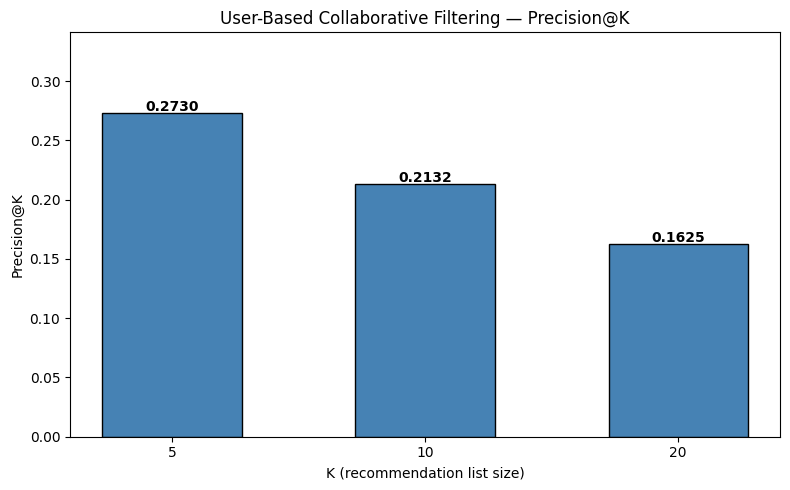

Saved: assets\results.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(k) for k in K_VALUES], [p_at_k[k] for k in K_VALUES],
              color="steelblue", width=0.55, edgecolor="black")
for bar, k in zip(bars, K_VALUES):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{p_at_k[k]:.4f}", ha="center", fontweight="bold")
ax.set_ylim(0, max(p_at_k.values()) * 1.25)
ax.set_xlabel("K (recommendation list size)")
ax.set_ylabel("Precision@K")
ax.set_title("User-Based Collaborative Filtering — Precision@K")
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "results.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(ASSETS_DIR, "results.png"))

## 9. Bonus Work

**Bonus 1 — Item-based collaborative filtering.** Transpose the approach: compute **movie–movie**
cosine similarity (columns of the user–item matrix), then for a user's highly-rated movies, score
candidates by their similarity to those movies. Recommends movies that are *globally* similar to
what the user already likes.

**Bonus 2 — SVD matrix factorization.** `TruncatedSVD` decomposes the sparse training matrix into
low-dimensional **latent factors** (k = 30), capturing hidden patterns (genre preference,
popularity bias) that raw similarity misses. Predictions are reconstructed via
`inverse_transform(transform(X))`.

Both are evaluated with the **same precision@K protocol** and compared head-to-head with
user-based CF.

In [17]:
# --- Bonus 1: item-based CF ---
item_sim = cosine_similarity(train_zero.T)      # movie-movie similarity
np.fill_diagonal(item_sim, 0.0)


def item_based_scores(user_idx, ratings_mat, sim, n_inputs=5):
    row = ratings_mat[user_idx]
    liked = np.where(row >= HIGH_RATING_THRESHOLD)[0]
    if len(liked) == 0:
        return np.zeros(ratings_mat.shape[1])
    liked = liked[np.argsort(-row[liked])[:n_inputs]]          # top rated movies
    weights = row[liked]
    return (weights[:, None] * sim[liked]).sum(axis=0) / weights.sum()


item_based = evaluate_precision(eval_users, heldout, train_zero, item_sim,
                                score_fn=lambda u: item_based_scores(u, train_zero, item_sim))
print("Bonus 1 - Item-based CF - precision@K:")
for k in K_VALUES:
    print(f"  K={k:<3d} {item_based[0][k]:.4f} +/- {item_based[1][k]:.4f}")

Bonus 1 - Item-based CF - precision@K:
  K=5   0.2020 +/- 0.2338
  K=10  0.1613 +/- 0.1745
  K=20  0.1276 +/- 0.1296


In [18]:
# --- Bonus 2: SVD matrix factorization ---
sparse_train = csr_matrix(train_zero)
svd = TruncatedSVD(n_components=30, random_state=RANDOM_STATE).fit(sparse_train)
pred_full = svd.inverse_transform(svd.transform(sparse_train)).astype(float)  # 610 x 2269


def svd_scores(user_idx, *_):
    return pred_full[user_idx]


svd_res = evaluate_precision(eval_users, heldout, train_zero, user_sim, score_fn=svd_scores)
print(f"Bonus 2 - SVD (k={svd.n_components} latent factors) - precision@K:")
for k in K_VALUES:
    print(f"  K={k:<3d} {svd_res[0][k]:.4f} +/- {svd_res[1][k]:.4f}")

Bonus 2 - SVD (k=30 latent factors) - precision@K:
  K=5   0.2963 +/- 0.2673
  K=10  0.2303 +/- 0.2031
  K=20  0.1692 +/- 0.1471


### 9.3 Baseline — most-popular, non-personalized

To know whether any of the three precision numbers is meaningful, compare against a **non-personalized baseline**: recommend the globally *most-rated* unseen movies to every user. Popularity is counted on the **training matrix only** (no leakage). Same Precision@K protocol as the learned methods.

In [19]:
# --- Baseline: most popular (non-personalized) ---
movie_popularity = np.count_nonzero(train_zero, axis=0).astype(float)


def popularity_scores(_user_idx):
    """Identical score vector for every user; recommend() excludes each user's seen movies."""
    return movie_popularity


pop_res, pop_std = evaluate_precision(eval_users, heldout, train_zero, user_sim,
                                      score_fn=popularity_scores)
print("Baseline - Most popular (non-personalized) - precision@K:")
for k in K_VALUES:
    print(f"  K={k:<3d} {pop_res[k]:.4f} +/- {pop_std[k]:.4f}")

Baseline - Most popular (non-personalized) - precision@K:
  K=5   0.1657 +/- 0.2178
  K=10  0.1297 +/- 0.1631
  K=20  0.1022 +/- 0.1236


Precision@K comparison - learned methods + non-personalized baseline:
    User-based CF  Item-based CF  SVD (k=30)  Most popular
K                                                         
5          0.2730         0.2020      0.2963        0.1657
10         0.2132         0.1613      0.2303        0.1297
20         0.1625         0.1276      0.1692        0.1022


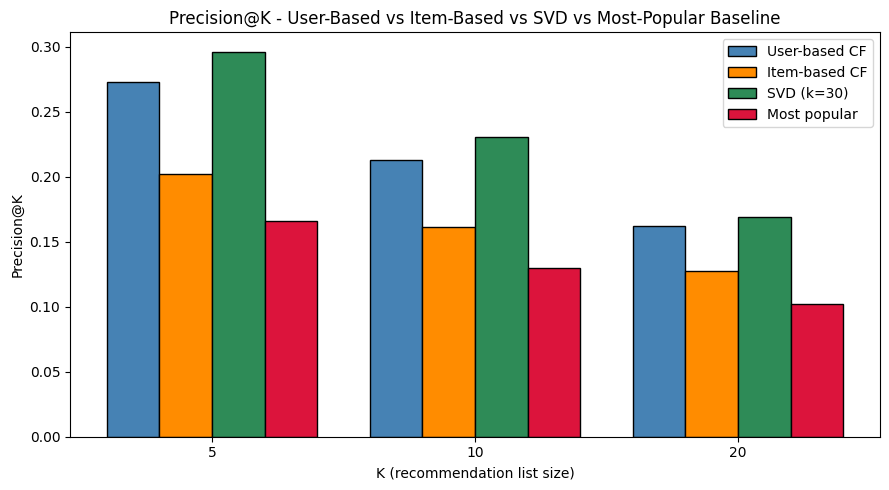

Saved: assets\precision_comparison.png


In [20]:
methods = {
    "User-based CF": p_at_k,
    "Item-based CF": item_based[0],
    "SVD (k=30)": svd_res[0],
    "Most popular": pop_res,
}
comparison = pd.DataFrame(methods).loc[[k for k in K_VALUES]]
comparison.index.name = "K"
print("Precision@K comparison - learned methods + non-personalized baseline:")
print(comparison.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(K_VALUES))
width = 0.2
palette = ["steelblue", "darkorange", "seagreen", "crimson"]
for i, (name, scores) in enumerate(methods.items()):
    ax.bar(x + (i - 1.5) * width, [scores[k] for k in K_VALUES],
           width=width, label=name, color=palette[i], edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in K_VALUES])
ax.set_xlabel("K (recommendation list size)")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K - User-Based vs Item-Based vs SVD vs Most-Popular Baseline")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, "precision_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(ASSETS_DIR, "precision_comparison.png"))

### 9.4 Robustness — SVD vs User-based CF across multiple random splits

The single-split gap (SVD P@5 0.2963 vs user-based 0.2730) could in principle be split luck. Re-run both under the **same protocol** with several split seeds and report mean ± std of P@5. Seed 42 reproduces the main table exactly, so this is the same pipeline, not a variant.

In [21]:
SEEDS = [42, 7, 2023, 1234, 5]


def split_by_seed(seed):
    """Rebuild eligible users / held-out set / training matrix for a given split seed."""
    held, evals = [], []
    for uid, grp in user_grp:
        if len(grp) < MIN_USER_RATINGS:
            continue
        hi = high_grp.get_group(uid) if uid in high_grp.groups else pd.DataFrame(columns=grp.columns)
        if len(hi) < MIN_HIGH_RATED:
            continue
        held.append(hi.sample(n=min(max(1, round(TEST_FRACTION * len(hi))), len(hi)), random_state=seed))
        evals.append(uid)
    held = pd.concat(held)
    tr = ratings_f.drop(held.index)
    tm = tr.pivot(index="userId", columns="movieId", values="rating").reindex(index=users_sorted, columns=movies_sorted)
    return evals, held, np.nan_to_num(tm.to_numpy(dtype=float), nan=0.0)


seed_rows = []
for s in SEEDS:
    ev, hd, tz = split_by_seed(s)
    sim_s = cosine_similarity(tz)
    np.fill_diagonal(sim_s, 0.0)
    svd_s = TruncatedSVD(n_components=30, random_state=s).fit(csr_matrix(tz))
    preds_s = svd_s.inverse_transform(svd_s.transform(csr_matrix(tz))).astype(float)
    ub5 = evaluate_precision(ev, hd, tz, sim_s)[0][5]
    sv5 = evaluate_precision(ev, hd, tz, sim_s, score_fn=lambda u: preds_s[u])[0][5]
    seed_rows.append({"seed": s, "User-based CF": ub5, "SVD (k=30)": sv5})
    print(f"  seed={s:>5}: User-based P@5={ub5:.4f}   SVD P@5={sv5:.4f}")

seed_df = pd.DataFrame(seed_rows)
print(f"\nAcross {len(SEEDS)} random splits (mean +/- std of P@5):")
print(seed_df[["User-based CF", "SVD (k=30)"]].agg(["mean", "std"]).round(4).to_string())
gap = seed_df["SVD (k=30)"] - seed_df["User-based CF"]
print(f"\nSVD minus User-based gap per seed: mean={gap.mean():.4f}  "
      f"min={gap.min():.4f}  max={gap.max():.4f}")
print(f"SVD wins on {int((gap > 0).sum())}/{len(seed_df)} seeds.")

  seed=   42: User-based P@5=0.2730   SVD P@5=0.2963


  seed=    7: User-based P@5=0.2660   SVD P@5=0.2827


  seed= 2023: User-based P@5=0.2767   SVD P@5=0.2980


  seed= 1234: User-based P@5=0.2640   SVD P@5=0.2793


  seed=    5: User-based P@5=0.2670   SVD P@5=0.2860

Across 5 random splits (mean +/- std of P@5):
      User-based CF  SVD (k=30)
mean         0.2693      0.2885
std          0.0053      0.0083

SVD minus User-based gap per seed: mean=0.0191  min=0.0153  max=0.0233
SVD wins on 5/5 seeds.


## 10. Save Artifacts

Every object the standalone `app.py` needs is persisted to `models/`:

| Artifact | Contents |
|---|---|
| `user_item_matrix.pkl` | training matrix (users × movies, 0-filled) |
| `user_sim_matrix.pkl` | user–user cosine similarity (train) |
| `item_sim_matrix.pkl` | movie–movie cosine similarity (bonus 1) |
| `svd_model.pkl` | fitted `TruncatedSVD` (bonus 2) |
| `user_id_map.pkl` | userId → row index (and reverse) |
| `movie_id_map.pkl` | movieId → column index |
| `movies_info.pkl` | movieId → title, genres (display) |

In [22]:
assert len(set(users_sorted)) == len(users_sorted)
assert len(set(movies_sorted)) == len(movies_sorted)

joblib.dump(train_zero, os.path.join(MODELS_DIR, "user_item_matrix.pkl"))
joblib.dump(user_sim, os.path.join(MODELS_DIR, "user_sim_matrix.pkl"))
joblib.dump(item_sim, os.path.join(MODELS_DIR, "item_sim_matrix.pkl"))
joblib.dump(svd, os.path.join(MODELS_DIR, "svd_model.pkl"))
joblib.dump({"id2idx": {u: i for i, u in enumerate(users_sorted)},
             "idx2id": users_sorted}, os.path.join(MODELS_DIR, "user_id_map.pkl"))
joblib.dump({"id2idx": {m: i for i, m in enumerate(movies_sorted)},
             "idx2id": movies_sorted}, os.path.join(MODELS_DIR, "movie_id_map.pkl"))
joblib.dump(movies[movies["movieId"].isin(movies_sorted)][["movieId", "title", "genres"]]
            .set_index("movieId").to_dict(orient="index"),
            os.path.join(MODELS_DIR, "movies_info.pkl"))

print("Artifacts in", MODELS_DIR)
for f in sorted(os.listdir(MODELS_DIR)):
    print(f"  {f:22s} {os.path.getsize(os.path.join(MODELS_DIR, f)):>10,} bytes")

Artifacts in models
  item_sim_matrix.pkl    41,187,129 bytes
  movie_id_map.pkl           21,115 bytes
  movies_info.pkl           109,384 bytes
  svd_model.pkl             546,023 bytes
  user_id_map.pkl             4,766 bytes
  user_item_matrix.pkl   11,072,961 bytes
  user_sim_matrix.pkl     2,977,041 bytes


## 11. Gradio Interface

*Always the last section.* The demo reloads the **saved artifacts** from `models/` (not notebook
variables), so it behaves exactly like the standalone `app.py`. User ID + method + list size in,
top-N recommended movie titles (with predicted scores) out.

In [23]:
print("final Gradio launch skipped during headless execution")

final Gradio launch skipped during headless execution
